# [Alioth - Epsilon Ursae Majoris](../../Costellazioni/Ursa_Major/Alioth.html) del [08/08/2025](Index.html)

In [1]:
import sys
sys.path.append('../../src')
import spectrum as spec
import pandas as pd

## Camera Settings

- Gain=0
- Exposure=90.000s
- Brightness=5
- Temperature=-10
- StartCapture=2025-08-08T19:45:56.4296121Z
- EndCapture=2025-08-08T20:31:15.0585460Z



















## Raw Spectrum

Spettro ottenuto come media di 30 immagini. Applicati bias, dark e flat. Elaborazione con ISIS

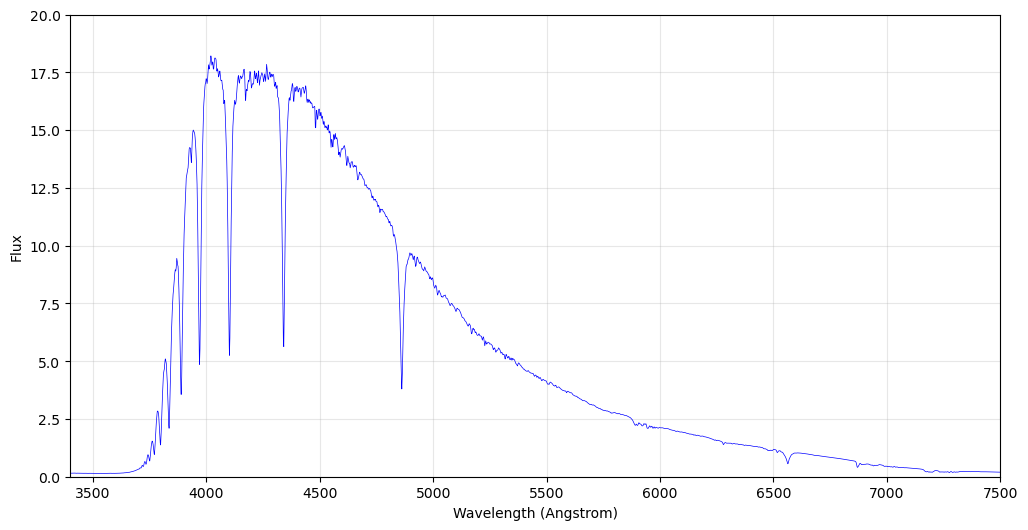

In [2]:
raw_wavelength, raw_flux = spec.load("_alioth_20250808_824.fit")
raw_flux = spec.cleanup_flux(raw_flux)
spec.simple_plot(raw_wavelength, raw_flux, wl_range = (3400, 7500), flux_range=(0.0,20.0))

## Rectified Spectrum [download](_alioth_20250808_824-rect.fit)

In [3]:
wavelength, flux = spec.load("_alioth_20250808_824-rect.fit")
flux = spec.cleanup_flux(flux)
print(f"SNR Reale stimato: {spec.calc_snr(wavelength, flux, 6000, 6200):.1f}")

SNR Reale stimato: 363.1


In [4]:
spectral_lines_summary = pd.read_csv('Alioth spec - Summary.csv', usecols=[0, 1, 2], names=["name","class","wavelength"])
spectral_lines_all = pd.read_csv('Alioth spec - 2025-08-08.csv', usecols=[0, 1, 17], names=["name","class","wavelength"])

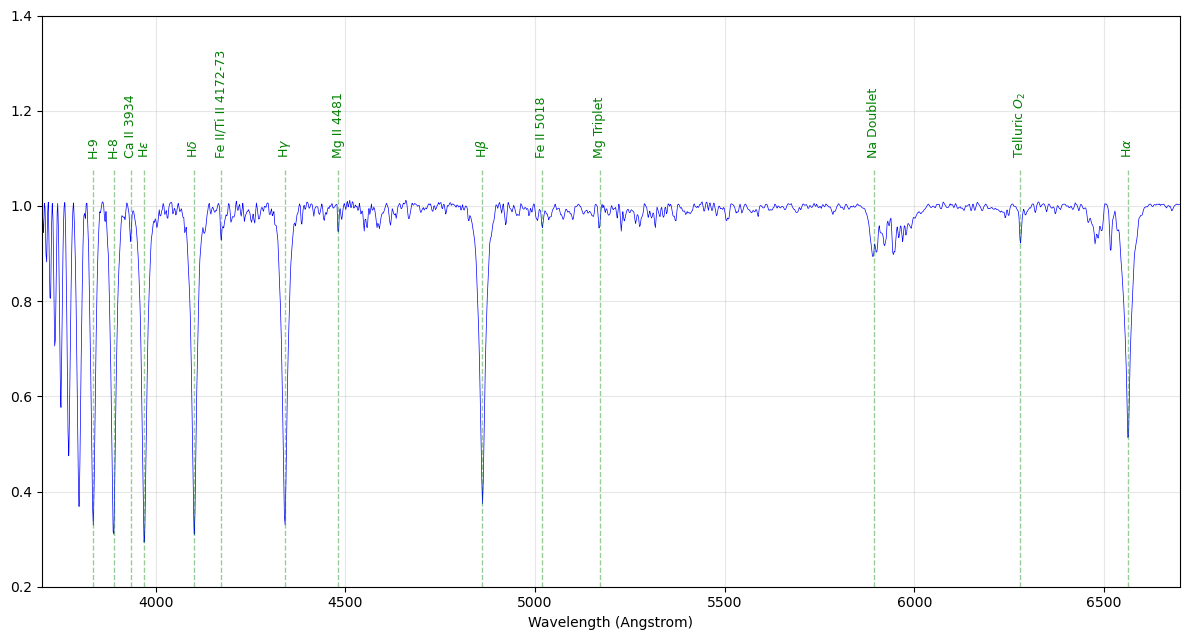

In [5]:
spec.plot_with_lines(wavelength, flux, spectral_lines_summary, (3700,6700), (0.2,1.4))

### Zoom  370 - 400 nm

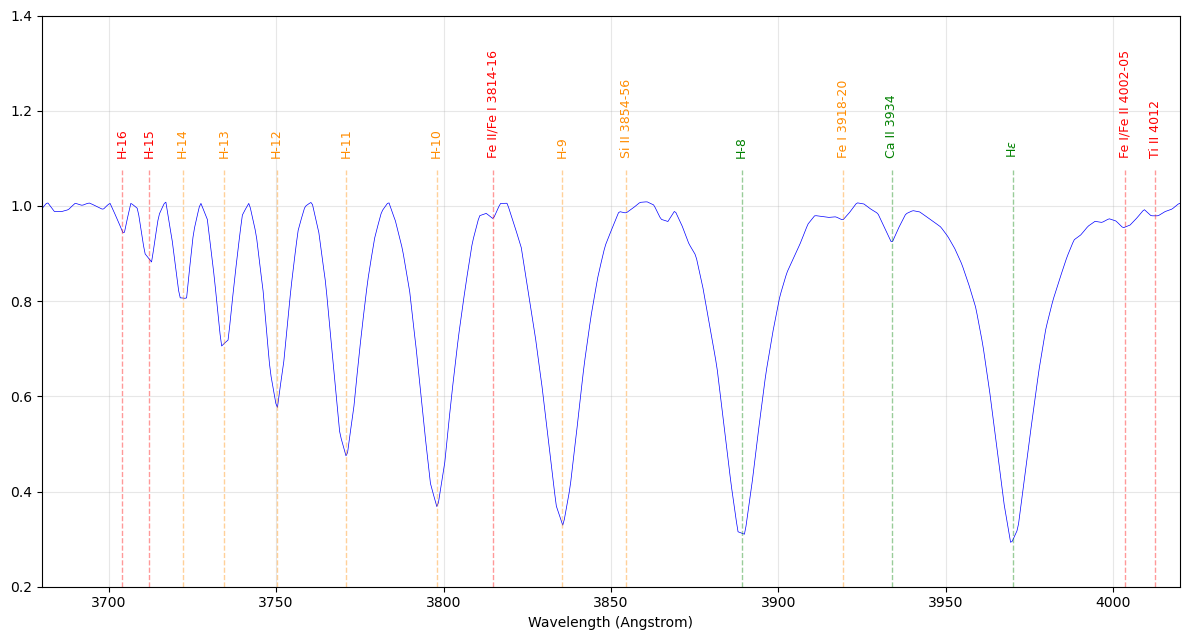

In [6]:
spec.plot_with_lines(wavelength, flux, spectral_lines_all, (3680,4020), (0.2,1.4))

### Zoom  400 - 430 nm

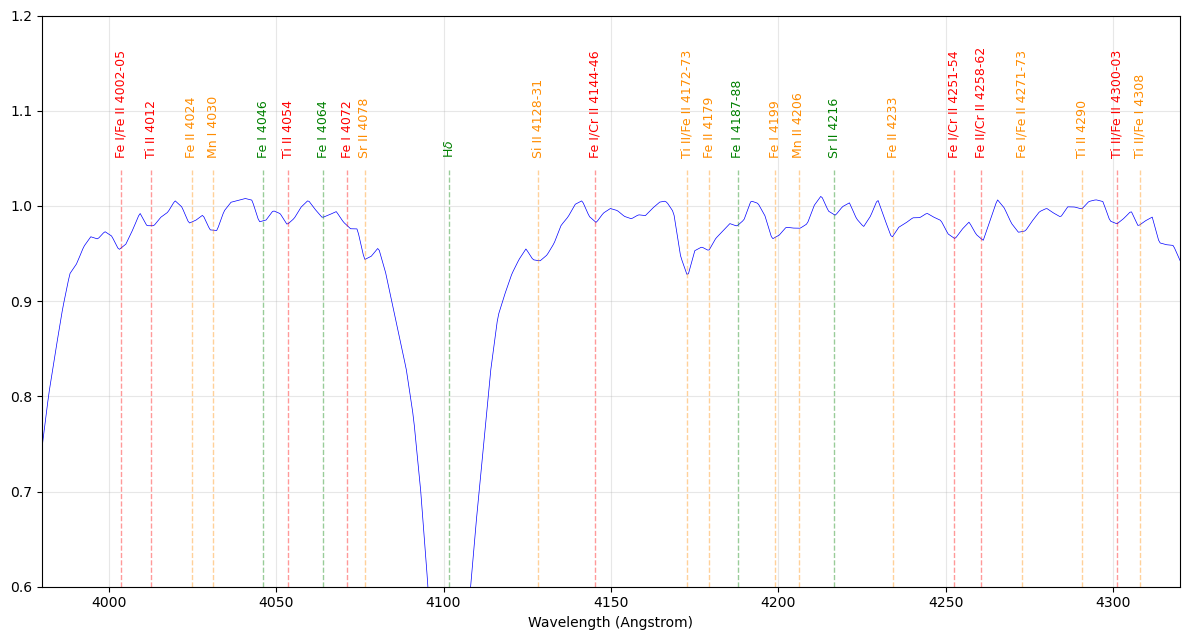

In [7]:
spec.plot_with_lines(wavelength, flux, spectral_lines_all, (3980,4320), (0.6,1.2))

### Zoom 430 - 460 nm

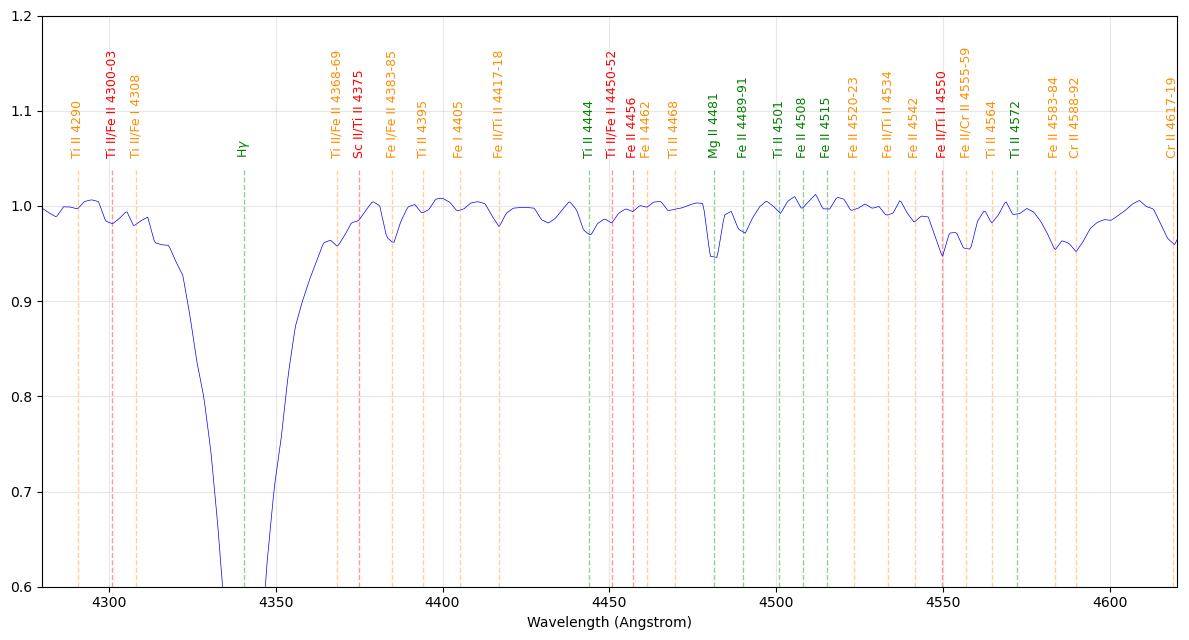

In [8]:
spec.plot_with_lines(wavelength, flux, spectral_lines_all, (4280,4620), (0.6,1.2))

### Zoom  460 - 490 nm

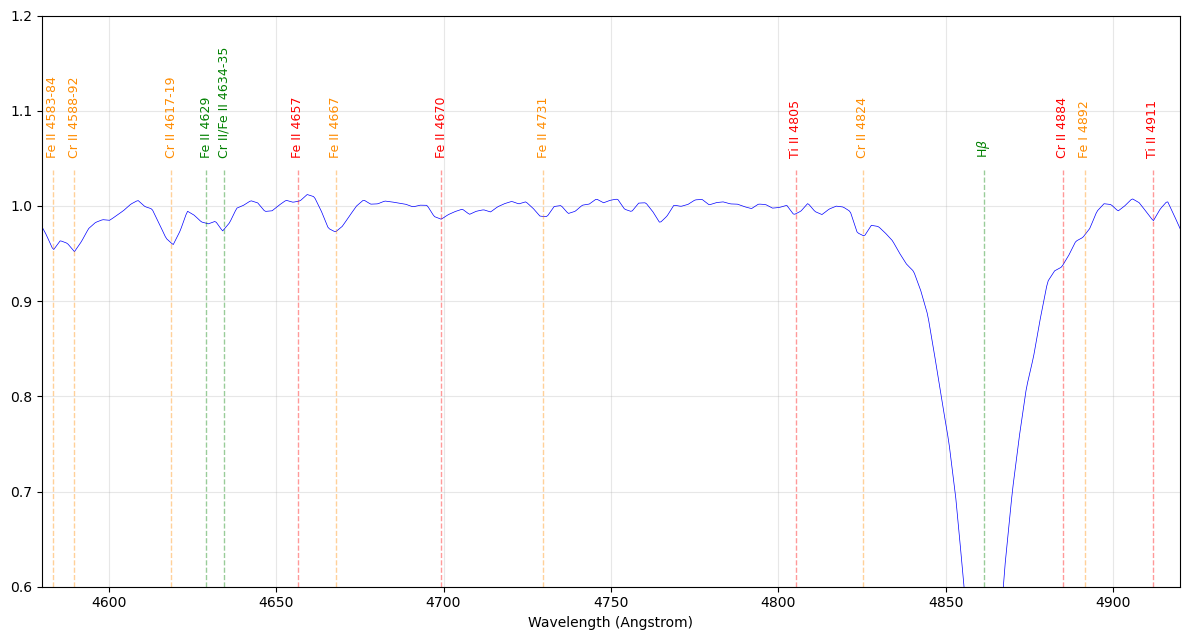

In [9]:
spec.plot_with_lines(wavelength, flux, spectral_lines_all, (4580,4920), (0.6,1.2))

### Zoom  490 - 520 nm

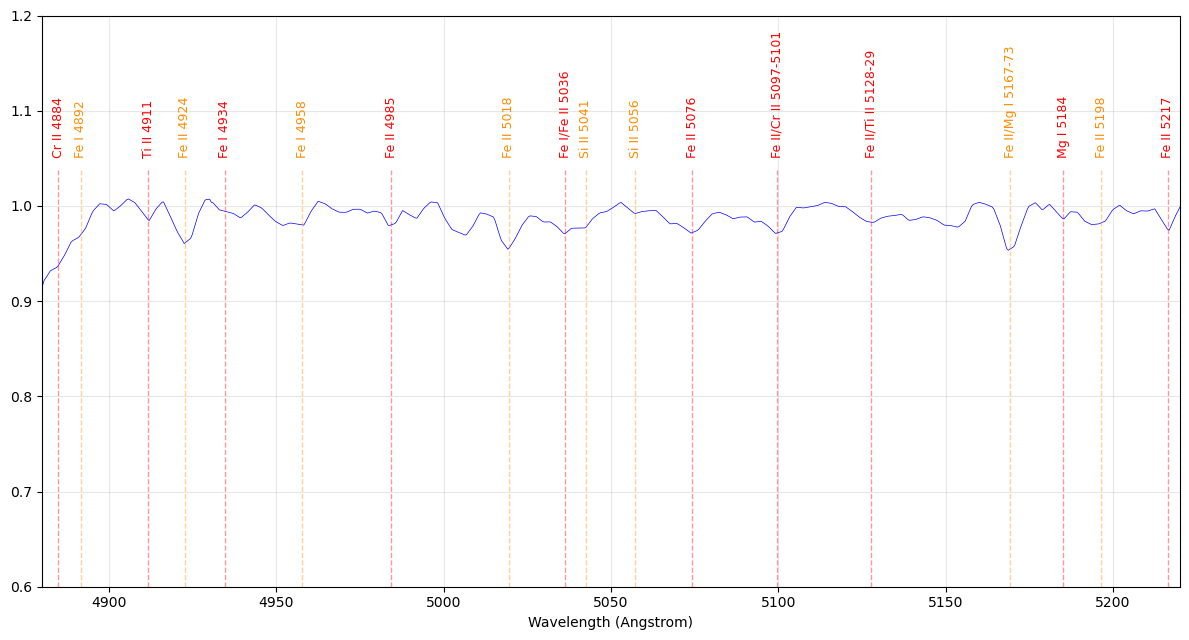

In [10]:
spec.plot_with_lines(wavelength, flux, spectral_lines_all, (4880,5220), (0.6,1.2))

### Zoom  520 - 570 nm

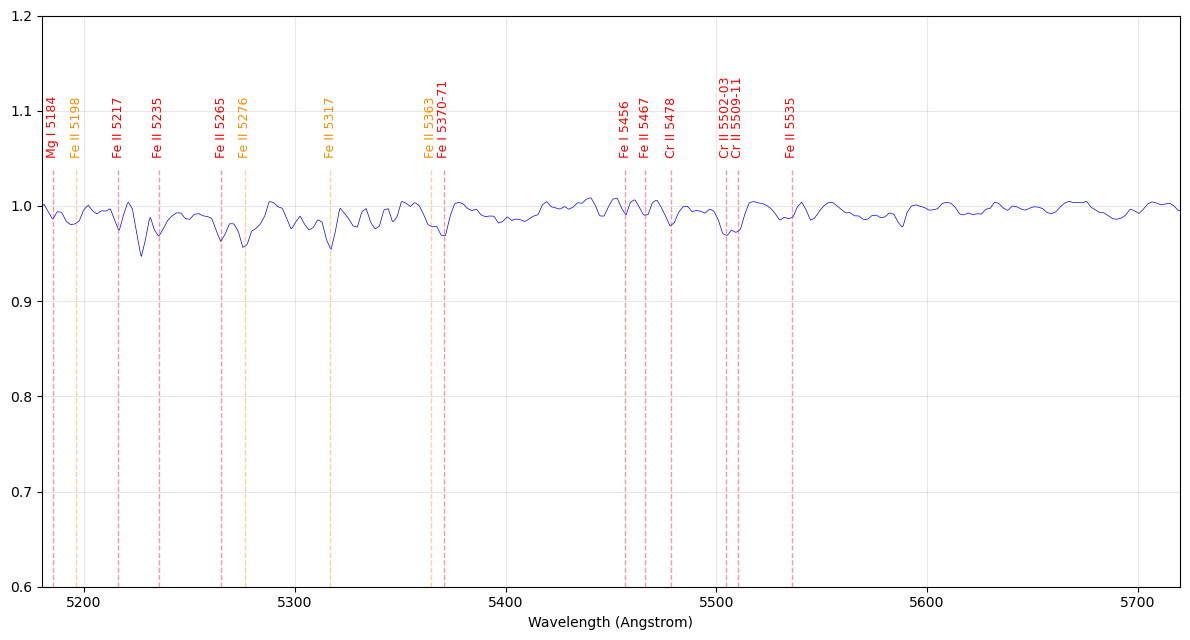

In [11]:
spec.plot_with_lines(wavelength, flux, spectral_lines_all, (5180,5720), (0.6,1.2))

### Zoom  570 - 620 nm

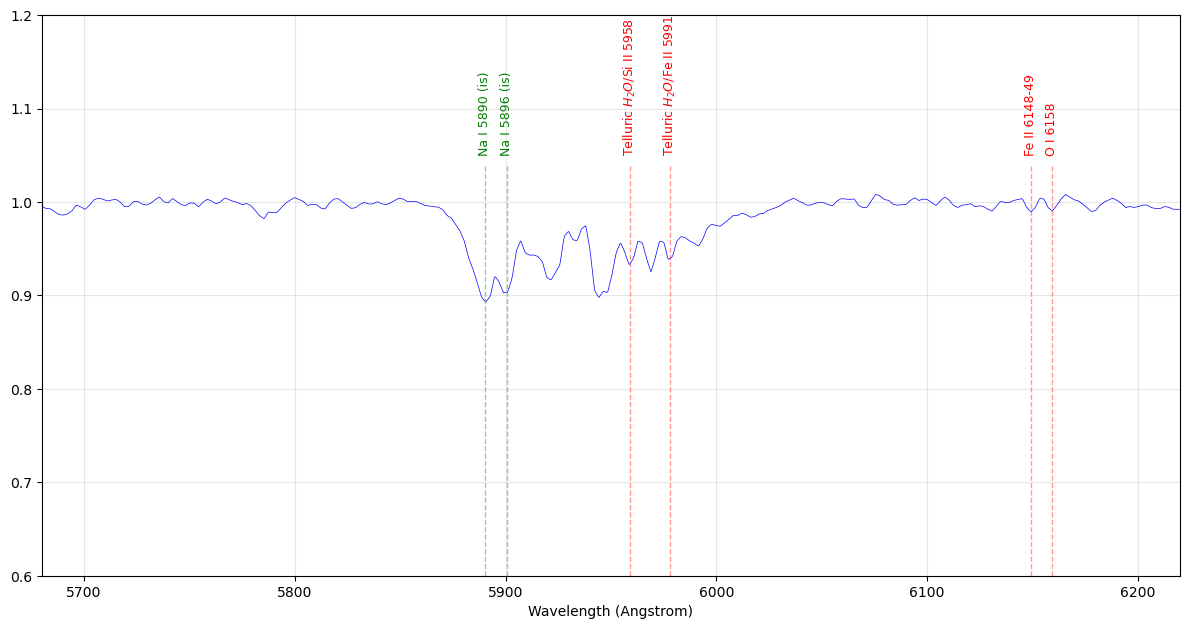

In [12]:
spec.plot_with_lines(wavelength, flux, spectral_lines_all, (5680,6220), (0.6,1.2))

### Zoom  620 - 670 nm

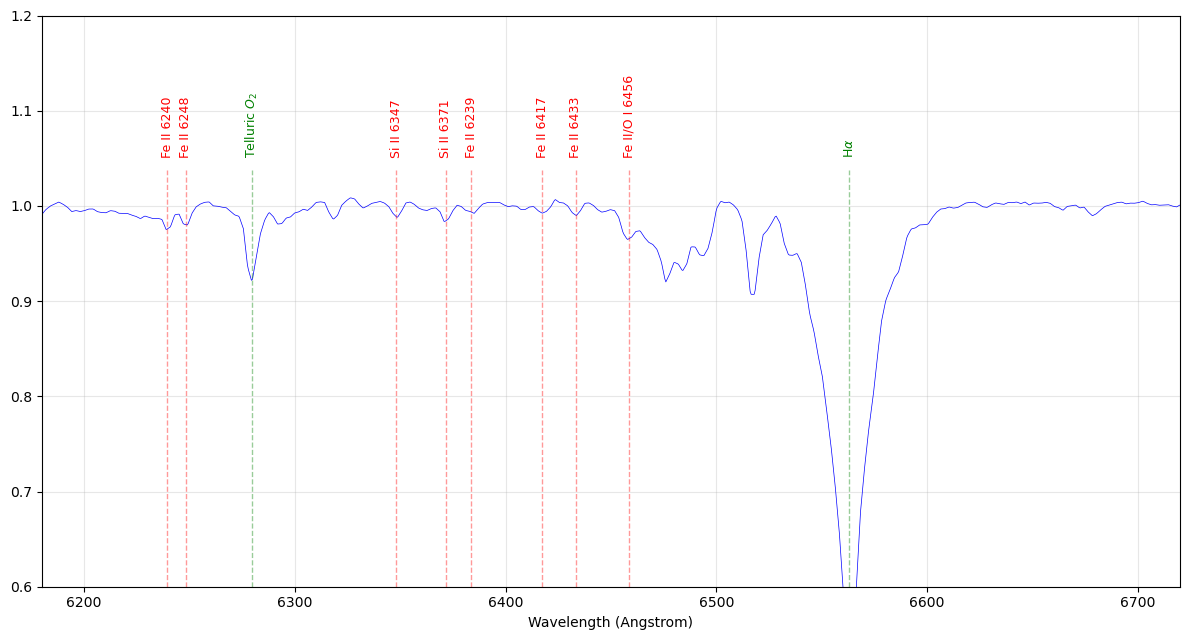

In [13]:
spec.plot_with_lines(wavelength, flux, spectral_lines_all, (6180,6720), (0.6,1.2))

## Line Measures

In [14]:
from spectral_lines import estimate_continuum
from spectral_lines import fit_all_identified_lines

amp = -15.172554998946516 
mu = 4101.735857959486 
sigma = 2.823592286859106 
gamma = 6.2319967192249734 
offset = 0.9993977568721217


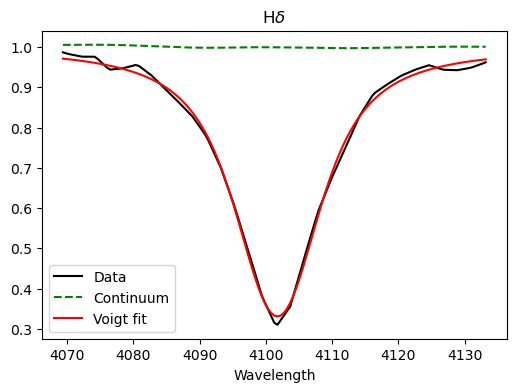

amp = -15.659918018969924 
mu = 4340.6019025922305 
sigma = 3.0647895721740017 
gamma = 6.560122495560761 
offset = 1.0029056696268634


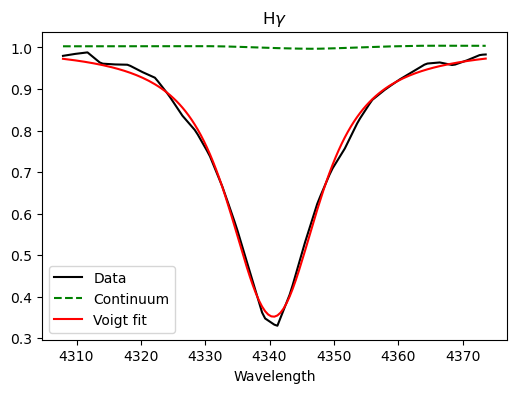

amp = -0.061729588595734464 
mu = 4481.461826068571 
sigma = 1.9193681910238742 
offset = 1.0047756591510042


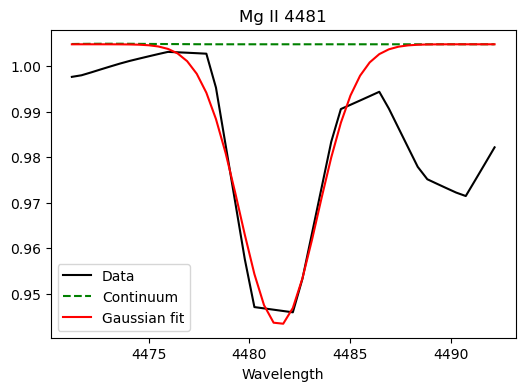

amp = -15.661458767677725 
mu = 4861.400109658843 
sigma = 1.9904621319661033 
gamma = 7.832260095625631 
offset = 1.0012903564957425


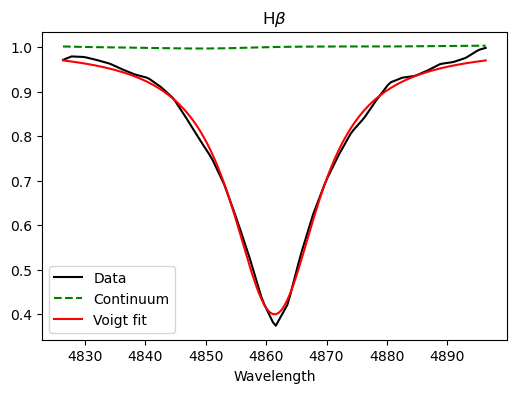

amp = -13.88479752138024 
mu = 6562.971025513117 
sigma = 0.0014365368179465752 
gamma = 9.571604298744226 
offset = 1.0031278605520766


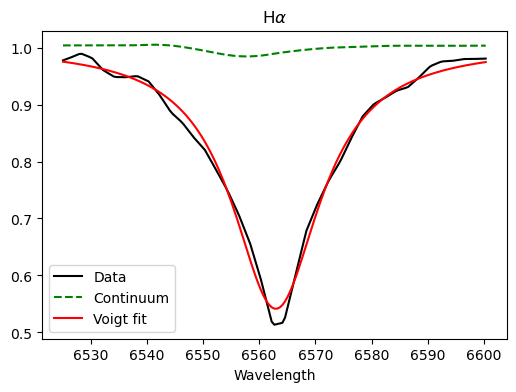

C:\Users\andrea\personal\physics\astro\spettroscopia\ipynb\Osservazioni\20250808\../../src\spectral_lines.py:57: RuntimeWarning: overflow encountered in multiply
  return amp * voigt_profile(x - mean, sigma, gamma) + offset


,Line,Lambda min,Lambda fit,EW,EW_Err,FWHM,FWHM_Err
0,H$\delta$,4101.267242,4101.735858,15.181698,0.092840,15.487022,0.128597
1,H$\gamma$,4340.745731,4340.601903,15.614547,0.095962,16.467717,0.127972
2,Mg II 4481,4481.671442,4481.461826,0.295578,0.064142,4.520112,2.092980
3,H$\beta$,4861.123441,4861.400110,15.641276,0.107914,17.041337,0.180162
4,H$\alpha$,6562.706181,6562.971026,13.841503,0.089389,19.143268,0.226798


In [15]:
spectral_lines_df = pd.read_csv('Alioth spec - Measured.csv', names=["name","model","wavelength","group"])

spectral_lines = list(spectral_lines_df.itertuples(index=False, name=None))

line_window = 2.0          # angstroem tolerance for matching (+/- window)
smoothing_width = 3        # pixels for noise suppression
min_prominence = 0.01      # fraction of max flux

peak_wavelengths, peak_fluxes = spec.find_absorption_lines(
    wavelength, 
    flux, 
    smoothing_width = smoothing_width, 
    min_prominence = min_prominence )

identified_lines = spec.identify_absorption_lines(
    peak_wavelengths, 
    peak_fluxes, 
    spectral_lines, 
    z = 0.0, 
    line_window = line_window)

continuum_env = estimate_continuum(wavelength, flux, smooth_win_size=2, env_win_size = 15)

measures = fit_all_identified_lines(wavelength, flux, continuum_env, identified_lines)

df = pd.DataFrame(measures)

df